# Transport provision

In [ ]:
import geopandas as gpd

## Data initialization

In [2]:
territory_gdf = gpd.read_file('data/data_provision/level_4_territories.geojson', engine='pyogrio').to_crs(32636)
road_gdf = gpd.read_file('data/data_provision/road.geojson').to_crs(32636)
railways_gdf = gpd.read_file('data/data_provision/railways.geojson').to_crs(32636)
water = gpd.read_file('data/data_provision/big water.geojson').to_crs(32636)
airport = gpd.read_file('data/data_provision/airport.geojson').to_crs(32636)
towns_gdf = gpd.read_file('data/data_provision/towns_with_status.geojson').to_crs(32636)

Cutting the water objects out

In [3]:
territory_gdf = territory_gdf.overlay(water, how='difference')
territory_gdf.head()

,territory_id,territory_type,parent,name,level,properties,admin_center,target_city_type,okato_code,oktmo_code,is_city,created_at,updated_at,geometry
0,3,"{ ""id"": 3, ""name"": ""Поселение"" }","{ ""id"": 2, ""name"": ""Бокситогорский муниципальн...",Самойловское сельское поселение,4,"{ ""Численность населения"": 2154, ""Администрати...","{ ""id"": 310, ""name"": ""поселок Совхозный"" }",None,41203876000,41603476,False,2024-06-16 21:35:40.802000+00:00,2024-11-14 12:17:52.704000+00:00,"POLYGON ((580049.515 6617067.720, 580225.344 6..."
1,4,"{ ""id"": 3, ""name"": ""Поселение"" }","{ ""id"": 2, ""name"": ""Бокситогорский муниципальн...",Большедворское сельское поселение,4,"{ ""Численность населения"": 1698, ""Администрати...","{ ""id"": 427, ""name"": ""деревня Большой Двор"" }",None,41203812000,41603412,False,2024-06-16 21:35:40.802000+00:00,2024-11-14 12:17:34.396000+00:00,"POLYGON ((573514.444 6620389.851, 573579.919 6..."
2,5,"{ ""id"": 3, ""name"": ""Поселение"" }","{ ""id"": 2, ""name"": ""Бокситогорский муниципальн...",Пикалевское городское поселение,4,"{ ""Численность населения"": 20169, ""Администрат...","{ ""id"": 335, ""name"": ""город Пикалево"" }",None,41440000000,41603102,False,2024-06-16 21:35:40.802000+00:00,2024-11-14 12:17:34.930000+00:00,"POLYGON ((564707.328 6594903.594, 564341.814 6..."
3,6,"{ ""id"": 3, ""name"": ""Поселение"" }","{ ""id"": 2, ""name"": ""Бокситогорский муниципальн...",Борское сельское поселение,4,"{ ""Численность населения"": 3393, ""Администрати...","{ ""id"": 2859, ""name"": ""деревня Бор"" }",None,41203816000,41603416,False,2024-06-16 21:35:40.802000+00:00,2024-11-14 12:17:35.368000+00:00,"POLYGON ((560629.509 6557332.762, 560642.857 6..."
4,7,"{ ""id"": 3, ""name"": ""Поселение"" }","{ ""id"": 2, ""name"": ""Бокситогорский муниципальн...",Бокситогорское городское поселение,4,"{ ""Численность населения"": 15960, ""Администрат...","{ ""id"": 328, ""name"": ""город Бокситогорск"" }",None,41403000000,41603101,False,2024-06-16 21:35:40.802000+00:00,2024-11-14 12:17:36.351000+00:00,"POLYGON ((560659.317 6585430.874, 559919.213 6..."


<Axes: >

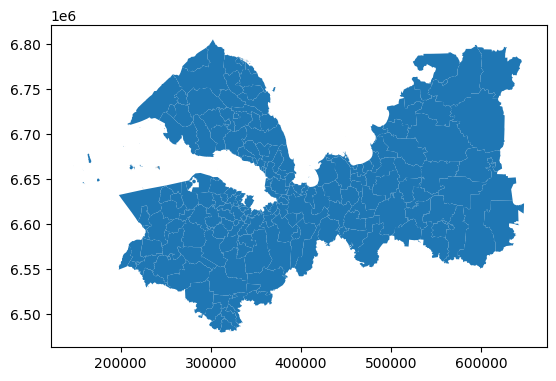

In [ ]:
territory_gdf.plot()

## Calculation

Trancport provision index is based on roads and railway lentgh in the territory polygon, the area of the territory, area of settlements and distance to the nearest airport.

In [4]:
from transport_frames.transport_provision import calculate_transport_provision

result = calculate_transport_provision(territory_gdf, road_gdf, railways_gdf, airport, towns_gdf)
result.head()

,geometry,area_km2,road_length_km,rail_length_km,airport_distance_km,town_area_km2,transport_provision_index
0,"POLYGON ((580049.515 6617067.720, 580225.344 6...",957.967302,116.705293,98.72176,45.297359,8.912560,0.181254
1,"POLYGON ((573514.444 6620389.851, 573579.919 6...",731.047141,129.137881,98.72176,20.104971,0.283352,0.216920
2,"POLYGON ((564707.328 6594903.594, 564341.814 6...",44.305614,61.902743,98.72176,33.811356,8.057840,1.398161
3,"POLYGON ((560629.509 6557332.762, 560642.857 6...",698.933242,80.400489,0.00000,36.217654,7.266476,0.138992
4,"POLYGON ((560659.317 6585430.874, 559919.213 6...",260.278008,83.271329,0.00000,27.234270,6.105861,0.200977


## Visualization

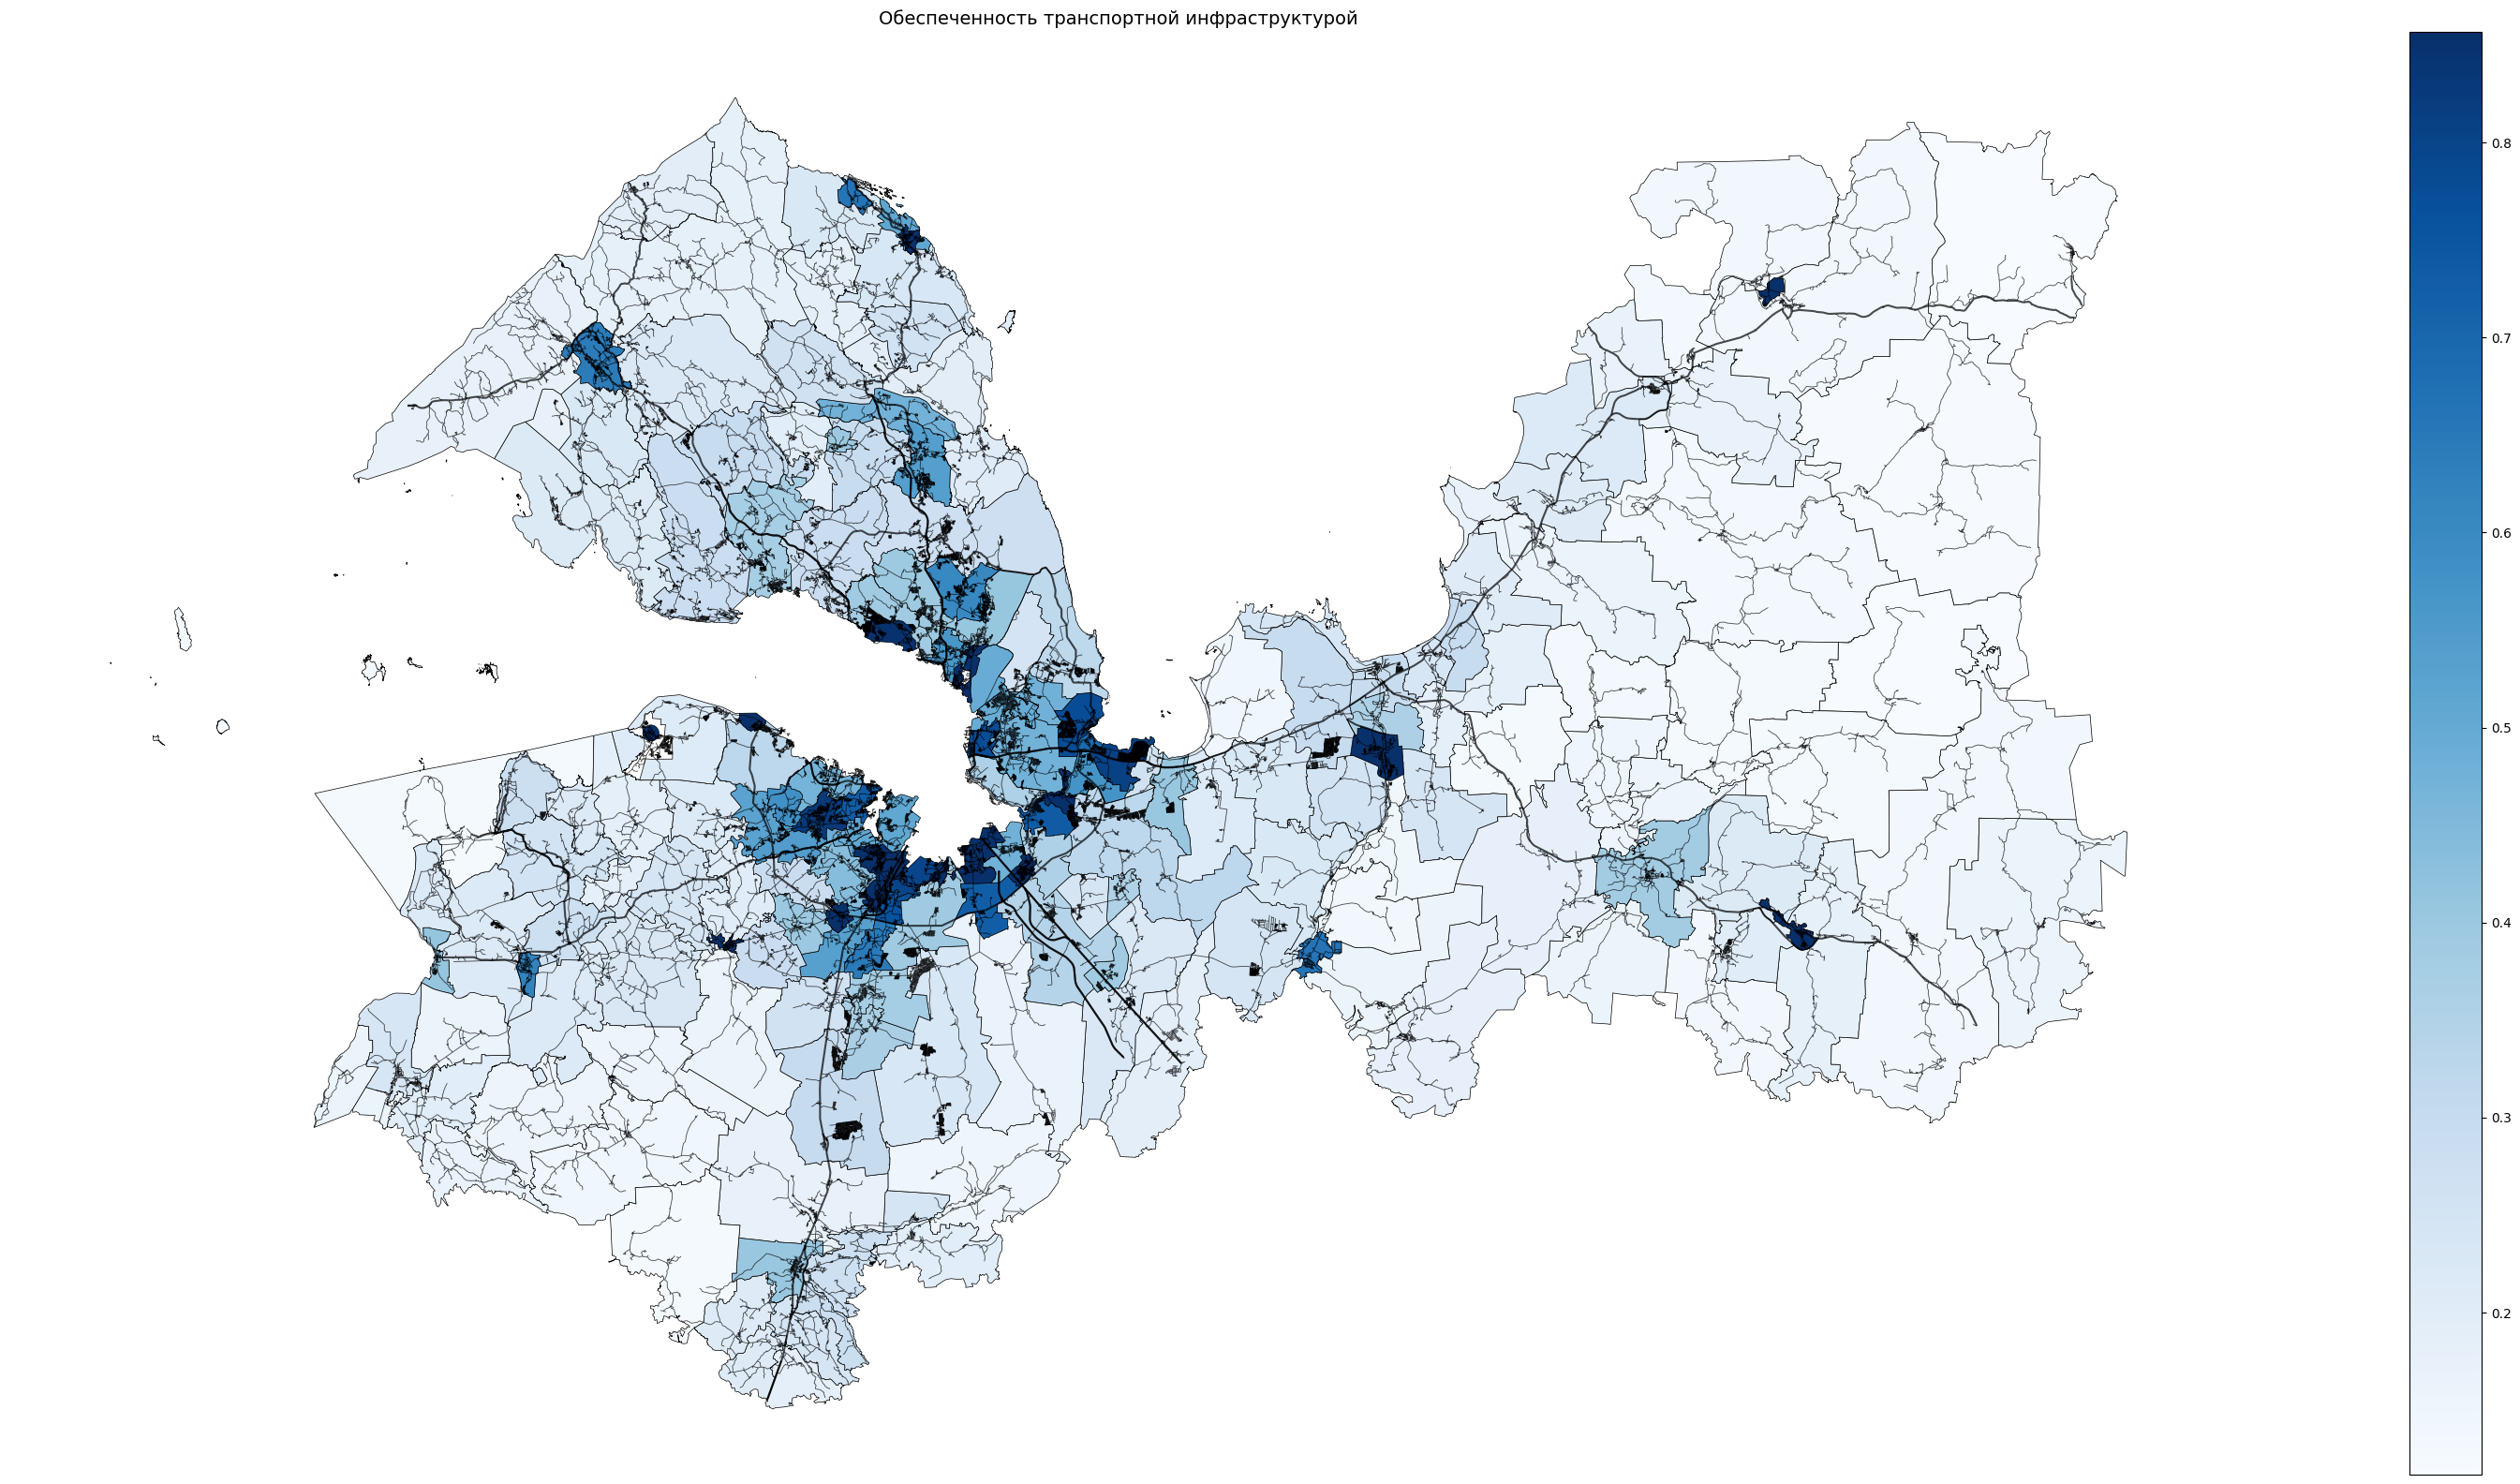

In [5]:
from transport_frames.transport_provision import visualize_transport_provision

visualize_transport_provision(result, road_gdf)